# Lab-4: Applied Statistical Modeling — Medical Insurance Costs
## Part 1, Task 1: Descriptive Metrics & Visual Exploration

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.precision", 3)

df = pd.read_csv("../data/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


### Central Tendency & Dispersion

In [2]:
numeric_cols = ["age", "bmi", "children", "charges"]

summary = df[numeric_cols].agg(["mean", "median", "std"]).T
summary["IQR"] = df[numeric_cols].quantile(0.75) - df[numeric_cols].quantile(0.25)
summary["skewness"] = [skew(df[c]) for c in numeric_cols]
summary["kurtosis"] = [kurtosis(df[c]) for c in numeric_cols]  # excess kurtosis (normal = 0)
summary

,mean,median,std,IQR,skewness,kurtosis
age,39.207,39.000,14.050,24.000,0.056,-1.245
bmi,30.663,30.400,6.098,8.398,0.284,-0.055
children,1.095,1.000,1.205,2.000,0.937,0.197
charges,13270.422,9382.033,12110.011,11899.625,1.514,1.596


### Distribution Plots (Histogram + KDE)

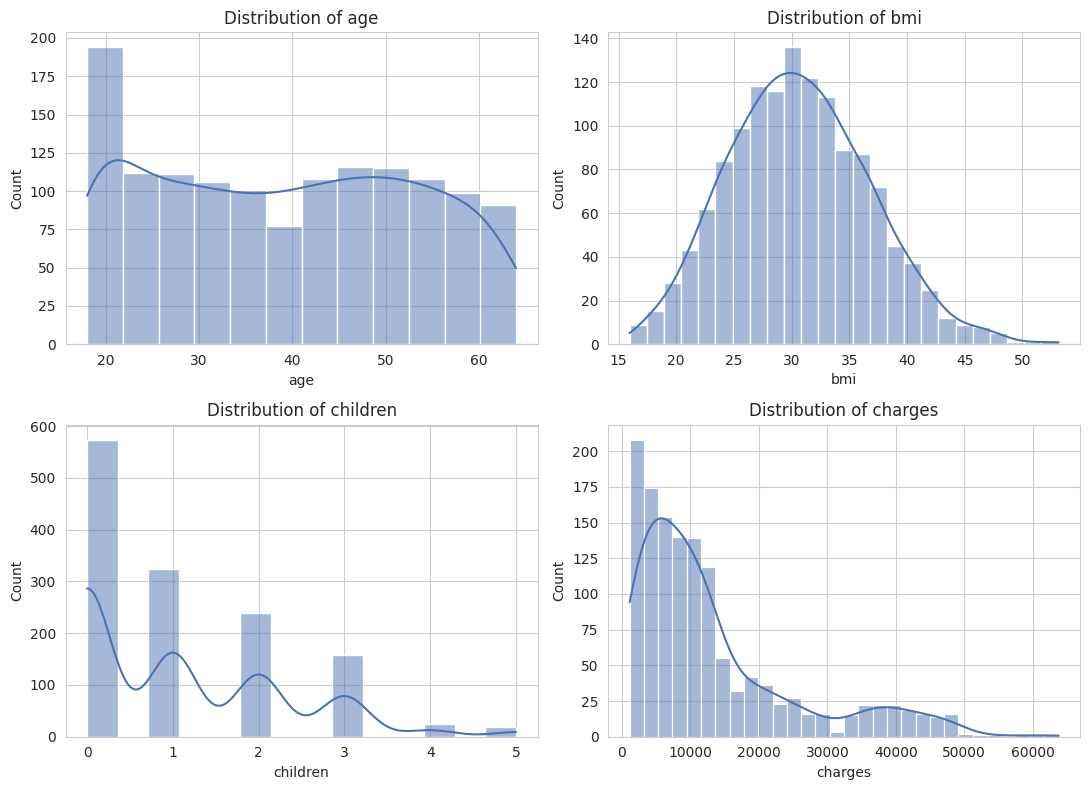

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.savefig("figures/distributions.png", dpi=120)
plt.show()

### Bivariate Scatter Plots

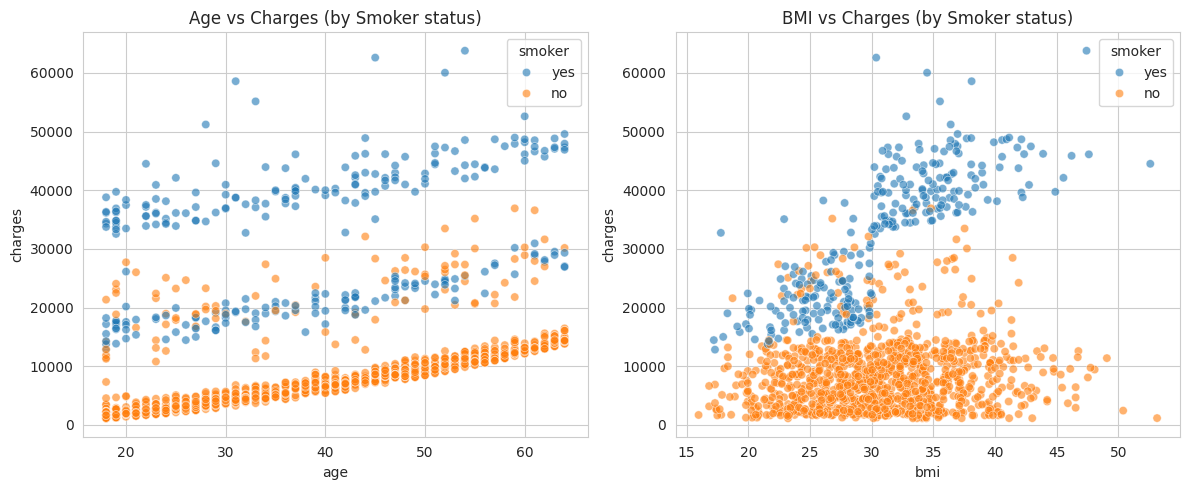

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", ax=axes[0], alpha=0.6)
axes[0].set_title("Age vs Charges (by Smoker status)")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=axes[1], alpha=0.6)
axes[1].set_title("BMI vs Charges (by Smoker status)")
plt.tight_layout()
plt.savefig("figures/scatter_age_bmi_charges.png", dpi=120)
plt.show()

### Correlation Matrix

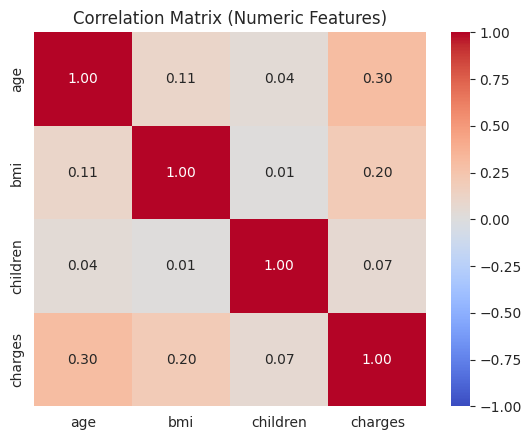

In [5]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Matrix (Numeric Features)")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=120)
plt.show()

## Part 1, Task 2: Hypothesis Test 1 — Smokers vs. Non-Smokers (Charges)

**H0:** No difference in mean/median `charges` between smokers and non-smokers.
**H1:** There is a significant difference.

**Procedure:** check normality (Shapiro-Wilk) within each group, check equal variance
(Levene's test) across groups, then pick t-test (parametric) or Mann-Whitney U
(non-parametric) accordingly.

In [6]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

smoker_charges = df.loc[df["smoker"] == "yes", "charges"]
nonsmoker_charges = df.loc[df["smoker"] == "no", "charges"]

print(f"n(smoker) = {len(smoker_charges)}, n(non-smoker) = {len(nonsmoker_charges)}")
print(f"mean(smoker)    = {smoker_charges.mean():,.2f}")
print(f"mean(non-smoker)= {nonsmoker_charges.mean():,.2f}")

n(smoker) = 274, n(non-smoker) = 1064
mean(smoker)    = 32,050.23
mean(non-smoker)= 8,434.27


### Step 1 — Normality Check (Shapiro-Wilk)

In [7]:
sw_smoker = shapiro(smoker_charges)
sw_nonsmoker = shapiro(nonsmoker_charges)

print(f"Smoker group:     W = {sw_smoker.statistic:.4f}, p = {sw_smoker.pvalue:.2e}")
print(f"Non-smoker group: W = {sw_nonsmoker.statistic:.4f}, p = {sw_nonsmoker.pvalue:.2e}")

alpha = 0.05
normal_smoker = sw_smoker.pvalue > alpha
normal_nonsmoker = sw_nonsmoker.pvalue > alpha
print(f"\nSmoker group normal at alpha=0.05?     {normal_smoker}")
print(f"Non-smoker group normal at alpha=0.05? {normal_nonsmoker}")

Smoker group:     W = 0.9396, p = 3.62e-09
Non-smoker group: W = 0.8729, p = 1.45e-28

Smoker group normal at alpha=0.05?     False
Non-smoker group normal at alpha=0.05? False


### Step 2 — Equal Variance Check (Levene's Test)

In [8]:
lev = levene(smoker_charges, nonsmoker_charges)
print(f"Levene's test: statistic = {lev.statistic:.4f}, p = {lev.pvalue:.2e}")
equal_var = lev.pvalue > alpha
print(f"Equal variances assumption holds at alpha=0.05? {equal_var}")

Levene's test: statistic = 332.6135, p = 1.56e-66
Equal variances assumption holds at alpha=0.05? False


### Step 3 — Test Selection & Execution

Since at least one group fails the Shapiro-Wilk normality check, the parametric
t-test's core assumption is violated -> use the **Mann-Whitney U test**
(non-parametric, compares distributions/medians via rank-sums) instead of the
two-sample t-test. Both are computed below for comparison.

In [9]:
# Parametric (for reference/comparison only — assumption violated)
t_stat, t_p = ttest_ind(smoker_charges, nonsmoker_charges, equal_var=equal_var)
print(f"[Reference] Two-sample t-test: t = {t_stat:.4f}, p = {t_p:.2e}")

# Non-parametric (the appropriate test here)
u_stat, u_p = mannwhitneyu(smoker_charges, nonsmoker_charges, alternative="two-sided")
print(f"Mann-Whitney U test: U = {u_stat:.2f}, p = {u_p:.2e}")

print(f"\nMedian (smoker):     {smoker_charges.median():,.2f}")
print(f"Median (non-smoker): {nonsmoker_charges.median():,.2f}")

conclusion = "Reject H0" if u_p < alpha else "Fail to Reject H0"
print(f"\nConclusion at alpha=0.05: {conclusion}")

[Reference] Two-sample t-test: t = 32.7519, p = 5.89e-103
Mann-Whitney U test: U = 284133.00, p = 5.27e-130

Median (smoker):     34,456.35
Median (non-smoker): 7,345.41

Conclusion at alpha=0.05: Reject H0


### Visual Confirmation

/tmp/ipykernel_469/819399780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="smoker", y="charges", order=["no", "yes"], palette="Set2")


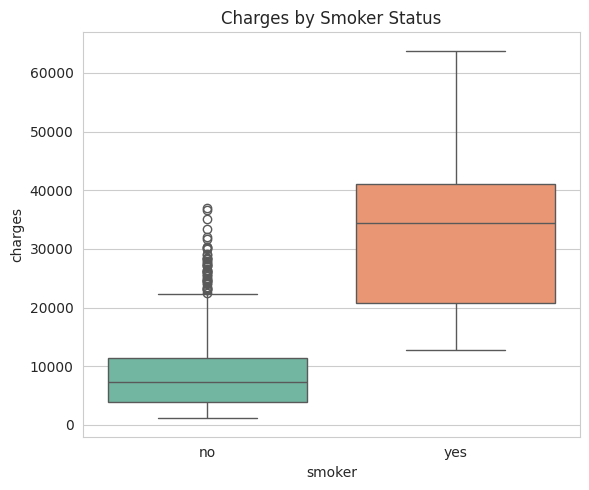

In [10]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x="smoker", y="charges", order=["no", "yes"], palette="Set2")
plt.title("Charges by Smoker Status")
plt.tight_layout()
plt.savefig("figures/smoker_boxplot.png", dpi=120)
plt.show()

## Part 1, Task 3: Hypothesis Test 2 — One-Way ANOVA (Charges Across Regions)

**H0:** Mean `charges` are equal across all four regions.
**H1:** At least one region's mean charges differs from the others.

**Procedure:** check normality per region (Shapiro-Wilk) and equal variance across
regions (Levene's), then run one-way ANOVA (or its non-parametric analogue,
Kruskal-Wallis, if assumptions fail).

In [11]:
regions = df["region"].unique()
region_groups = {r: df.loc[df["region"] == r, "charges"] for r in regions}

for r, g in region_groups.items():
    print(f"{r:12s} n={len(g):4d}  mean={g.mean():>10,.2f}  median={g.median():>10,.2f}")

southwest    n= 325  mean= 12,346.94  median=  8,798.59
southeast    n= 364  mean= 14,735.41  median=  9,294.13
northwest    n= 325  mean= 12,417.58  median=  8,965.80
northeast    n= 324  mean= 13,406.38  median= 10,057.65


### Step 1 — Normality Check per Region (Shapiro-Wilk)

In [12]:
from scipy.stats import shapiro, levene, f_oneway, kruskal

alpha = 0.05
sw_results = {}
for r, g in region_groups.items():
    sw = shapiro(g)
    sw_results[r] = sw
    print(f"{r:12s} W={sw.statistic:.4f}  p={sw.pvalue:.2e}  normal? {sw.pvalue > alpha}")

southwest    W=0.7843  p=2.02e-20  normal? False
southeast    W=0.8242  p=1.23e-19  normal? False
northwest    W=0.8128  p=4.27e-19  normal? False
northeast    W=0.8353  p=6.55e-18  normal? False


### Step 2 — Equal Variance Check (Levene's Test)

In [13]:
lev = levene(*region_groups.values())
print(f"Levene's test: statistic = {lev.statistic:.4f}, p = {lev.pvalue:.2e}")
equal_var = lev.pvalue > alpha
print(f"Equal variances across regions at alpha=0.05? {equal_var}")

Levene's test: statistic = 5.5600, p = 8.61e-04
Equal variances across regions at alpha=0.05? False


### Step 3 — Test Selection & Execution

Normality fails for at least one region, so strictly the non-parametric
**Kruskal-Wallis** test is the safer choice. The parametric **one-way ANOVA**
is also reported for comparison/reference, as ANOVA is reasonably robust to
mild normality violations with these group sizes.

In [14]:
f_stat, f_p = f_oneway(*region_groups.values())
print(f"[Reference] One-Way ANOVA: F = {f_stat:.4f}, p = {f_p:.4f}")

h_stat, h_p = kruskal(*region_groups.values())
print(f"Kruskal-Wallis: H = {h_stat:.4f}, p = {h_p:.4f}")

conclusion = "Reject H0" if h_p < alpha else "Fail to Reject H0"
print(f"\nConclusion at alpha=0.05 (Kruskal-Wallis): {conclusion}")

[Reference] One-Way ANOVA: F = 2.9696, p = 0.0309
Kruskal-Wallis: H = 4.7342, p = 0.1923

Conclusion at alpha=0.05 (Kruskal-Wallis): Fail to Reject H0


### Visual Confirmation

/tmp/ipykernel_469/946766351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="region", y="charges", order=order, palette="Set3")


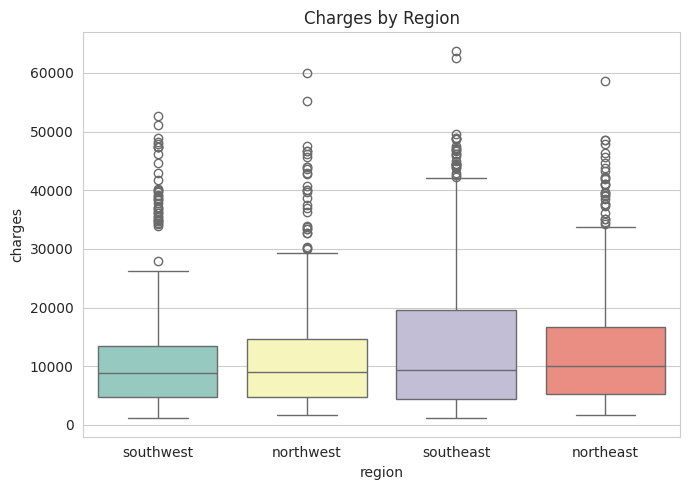

In [15]:
plt.figure(figsize=(7, 5))
order = df.groupby("region")["charges"].median().sort_values().index
sns.boxplot(data=df, x="region", y="charges", order=order, palette="Set3")
plt.title("Charges by Region")
plt.tight_layout()
plt.savefig("figures/region_boxplot.png", dpi=120)
plt.show()

# Part 2: Statistical Modeling & Diagnostic Checks
## Task 1: Model Formulation & Parameter Interpretation

Specification: `charges ~ age + bmi + children + sex + smoker + region + smoker:bmi`

The `smoker:bmi` interaction term is included because Task 1's scatter plots showed
charges rising steeply with BMI for smokers but staying flat for non-smokers — a
textbook interaction effect, not just two separate additive contributions.

In [16]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

model = smf.ols(
    "charges ~ age + bmi + children + C(sex) + C(smoker) * bmi + C(region)",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     780.0
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:47:27   Log-Likelihood:                -13248.
No. Observations:                1338   AIC:                         2.652e+04
Df Residuals:                    1328   BIC:                         2.657e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -2223

### Interpretation Notes

- **R² / Adjusted R²**: proportion of variance in `charges` explained by the model
  (adjusted version penalizes for the number of predictors, so compare that one
  when judging whether adding terms actually helped).
- **Coefficients (β)**: change in predicted `charges` for a one-unit increase in
  that predictor, holding all others constant.
- **`C(smoker)[T.yes]`**: the charges gap for a smoker at BMI = 0 (not directly
  meaningful alone since BMI=0 is outside the data range) — must be read
  *together* with the interaction term below.
- **`C(smoker)[T.yes]:bmi`**: the extra charges-per-BMI-unit that smokers pay on
  top of non-smokers. This is the interaction effect — expect this to be large
  and positive, confirming what the scatter plot showed.
- **p-values / 95% CIs**: a predictor is significant at alpha=0.05 if its p-value
  is below 0.05, equivalently if its 95% CI excludes 0.

In [17]:
# Clean coefficient table with CIs, for easy reference
coef_table = pd.DataFrame({
    "coef": model.params,
    "std_err": model.bse,
    "p_value": model.pvalues,
    "CI_lower_2.5%": model.conf_int()[0],
    "CI_upper_97.5%": model.conf_int()[1],
})
coef_table["significant_at_0.05"] = coef_table["p_value"] < 0.05
coef_table.round(3)

,coef,std_err,p_value,CI_lower_2.5%,CI_upper_97.5%,significant_at_0.05
Intercept,-2223.454,865.611,0.010,-3921.569,-525.339,True
C(sex)[T.male],-500.146,266.518,0.061,-1022.987,22.695,False
C(smoker)[T.yes],-20415.611,1648.277,0.000,-23649.122,-17182.101,True
C(region)[T.northwest],-585.478,380.859,0.124,-1332.630,161.674,False
C(region)[T.southeast],-1210.131,382.750,0.002,-1960.992,-459.270,True
C(region)[T.southwest],-1231.108,382.218,0.001,-1980.924,-481.291,True
age,263.620,9.516,0.000,244.952,282.288,True
bmi,23.533,25.601,0.358,-26.689,73.755,False
C(smoker)[T.yes]:bmi,1443.096,52.647,0.000,1339.816,1546.377,True
children,516.403,110.179,0.000,300.259,732.548,True


In [18]:
print(f"R-squared:          {model.rsquared:.4f}")
print(f"Adjusted R-squared:  {model.rsquared_adj:.4f}")
print(f"F-statistic:         {model.fvalue:.2f}  (p = {model.f_pvalue:.2e})")
print(f"N observations:      {int(model.nobs)}")

R-squared:          0.8409
Adjusted R-squared:  0.8398
F-statistic:         779.99  (p = 0.00e+00)
N observations:      1338


## Part 2: Statistical Modeling & Diagnostic Checks

### Model Formulation

Y = β0 + β1(age) + β2(sex) + β3(children) + β4(region) + β5(smoker) + β6(bmi) + β7(smoker × bmi) + ε

The `smoker × bmi` interaction term is included because Part 1's scatter plots showed
charges rising steeply with BMI *only* for smokers — a plain additive model would miss
this and force a single BMI slope onto both groups.

In [19]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols(
    "charges ~ age + C(sex) + children + C(region) + C(smoker) * bmi",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     780.0
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:47:27   Log-Likelihood:                -13248.
No. Observations:                1338   AIC:                         2.652e+04
Df Residuals:                    1328   BIC:                         2.657e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept              -2223

### Parameter Interpretation

- **R² / Adjusted R²**: proportion of variance in `charges` explained by the model
  (adjusted version penalizes for the number of predictors, fairer for comparison).
- **Coefficients (β)**: expected change in `charges` for a one-unit increase in that
  predictor, holding others constant (for the categorical dummies: relative to the
  reference category).
- **p-values**: whether each coefficient is statistically distinguishable from zero
  at conventional significance levels.
- **95% CI**: range of plausible values for each true coefficient.
- **`C(smoker)[T.yes]:bmi`**: the interaction term — the *extra* slope on `bmi` that
  applies specifically to smokers, on top of the main `bmi` effect.

In [20]:
coef_table = model.summary2().tables[1]
coef_table.columns = ["coef", "std_err", "t", "p_value", "ci_lower", "ci_upper"]
print(f"R-squared:          {model.rsquared:.4f}")
print(f"Adjusted R-squared: {model.rsquared_adj:.4f}\n")
coef_table.round(3)

R-squared:          0.8409
Adjusted R-squared: 0.8398



,coef,std_err,t,p_value,ci_lower,ci_upper
Intercept,-2223.454,865.611,-2.569,0.010,-3921.569,-525.339
C(sex)[T.male],-500.146,266.518,-1.877,0.061,-1022.987,22.695
C(region)[T.northwest],-585.478,380.859,-1.537,0.124,-1332.630,161.674
C(region)[T.southeast],-1210.131,382.750,-3.162,0.002,-1960.992,-459.270
C(region)[T.southwest],-1231.108,382.218,-3.221,0.001,-1980.924,-481.291
C(smoker)[T.yes],-20415.611,1648.277,-12.386,0.000,-23649.122,-17182.101
age,263.620,9.516,27.703,0.000,244.952,282.288
children,516.403,110.179,4.687,0.000,300.259,732.548
bmi,23.533,25.601,0.919,0.358,-26.689,73.755
C(smoker)[T.yes]:bmi,1443.096,52.647,27.411,0.000,1339.816,1546.377


## Gauss-Markov Diagnostic Checks

### 1. Linearity & Homoscedasticity — Residuals vs. Fitted

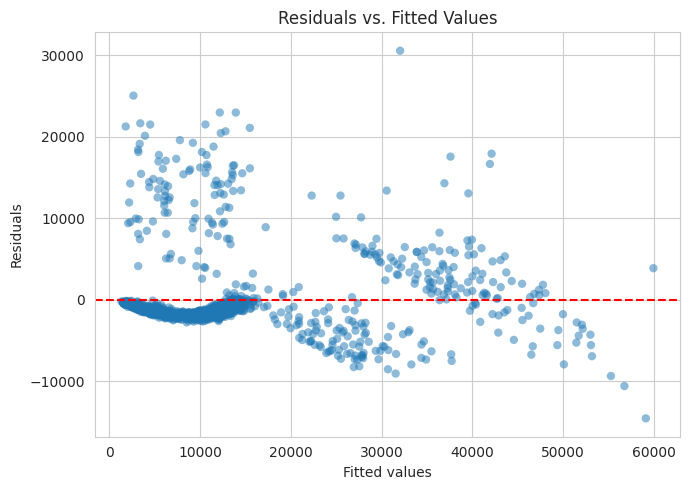

In [21]:
fitted = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(7, 5))
plt.scatter(fitted, residuals, alpha=0.5, edgecolor="none")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.tight_layout()
plt.savefig("figures/residuals_vs_fitted.png", dpi=120)
plt.show()

**What to look for:** residuals should scatter randomly around zero with no funnel
shape (funnel = heteroscedasticity) and no curve (curve = missing non-linear term).

### 2. Normality of Residuals — Q-Q Plot + Jarque-Bera/Omnibus

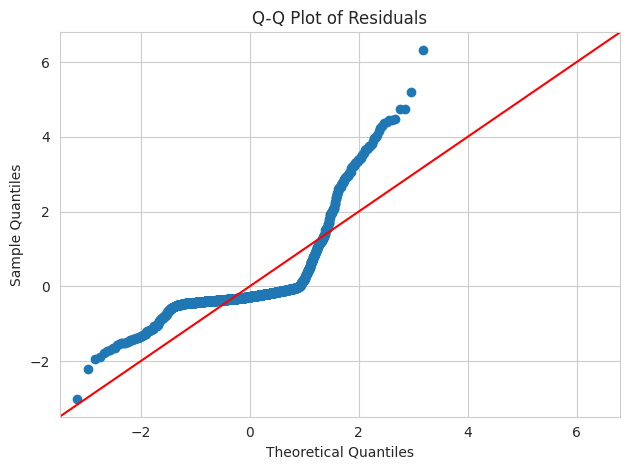


Jarque-Bera: statistic = 4465.2356, p = 0.00e+00
Residual skewness = 2.5287, kurtosis = 10.3835


In [22]:
fig = sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.savefig("figures/qq_plot.png", dpi=120)
plt.show()

print(f"Omnibus:       {model.diagnostic_omnibus[0]:.4f}, p = {model.diagnostic_omnibus[1]:.2e}" \
      if hasattr(model, "diagnostic_omnibus") else "")
jb_stat, jb_p, skew_r, kurt_r = sm.stats.jarque_bera(residuals)
print(f"Jarque-Bera: statistic = {jb_stat:.4f}, p = {jb_p:.2e}")
print(f"Residual skewness = {skew_r:.4f}, kurtosis = {kurt_r:.4f}")

### 3. Multicollinearity — Variance Inflation Factor (VIF)

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_df = df[["age", "bmi", "children"]].copy()
vif_df = sm.add_constant(vif_df)

vif_data = pd.DataFrame({
    "feature": vif_df.columns,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
})
vif_data = vif_data[vif_data["feature"] != "const"]
vif_data

,feature,VIF
1,age,1.014
2,bmi,1.012
3,children,1.002


**Interpretation:** VIF ≈ 1 → no multicollinearity. VIF > 5 (some use 10) signals a
predictor is highly explainable by the others and its coefficient estimate becomes
unstable/hard to interpret individually.

### Addressing the Diagnostic Violations — Log-Transformed Model

The raw model violates normality and homoscedasticity because `charges` itself is
right-skewed at the source (Task 1). A standard fix is modeling `log(charges)`
instead, which compresses the long right tail. Re-fitting and re-running the same
diagnostics below shows whether this resolves the Gauss-Markov violations.

In [24]:
log_model = smf.ols(
    "np.log(charges) ~ age + C(sex) + children + C(region) + C(smoker) * bmi",
    data=df
).fit()

print(log_model.summary())

                            OLS Regression Results                            
Dep. Variable:        np.log(charges)   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     534.0
Date:                Tue, 08 Sep 2026   Prob (F-statistic):               0.00
Time:                        05:47:27   Log-Likelihood:                -762.05
No. Observations:                1338   AIC:                             1544.
Df Residuals:                    1328   BIC:                             1596.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  7

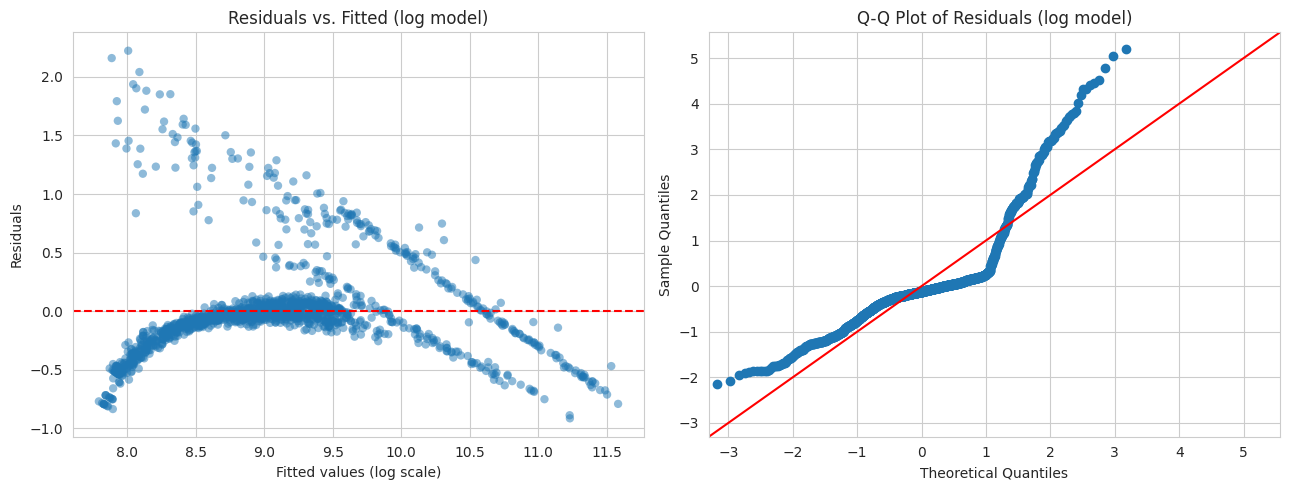

Raw model    -> R2=0.8409  JB p=0.00e+00  resid skew=2.529
Log model    -> R2=0.7835  JB p=0.00e+00  resid skew=1.846


In [25]:
log_fitted = log_model.fittedvalues
log_resid = log_model.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(log_fitted, log_resid, alpha=0.5, edgecolor="none")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Fitted values (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs. Fitted (log model)")

sm.qqplot(log_resid, line="45", fit=True, ax=axes[1])
axes[1].set_title("Q-Q Plot of Residuals (log model)")

plt.tight_layout()
plt.savefig("figures/log_model_diagnostics.png", dpi=120)
plt.show()

jb_stat2, jb_p2, skew2, kurt2 = sm.stats.jarque_bera(log_resid)
print(f"Raw model    -> R2={model.rsquared:.4f}  JB p={sm.stats.jarque_bera(residuals)[1]:.2e}  resid skew={sm.stats.jarque_bera(residuals)[2]:.3f}")
print(f"Log model    -> R2={log_model.rsquared:.4f}  JB p={jb_p2:.2e}  resid skew={skew2:.3f}")

**Result:** the log model's residuals are visibly better behaved — tighter band in
Residuals vs. Fitted (less funneling) and a Q-Q plot that hugs the 45° line far more
closely than the raw model, with lower residual skewness. It still isn't perfectly
normal (Jarque-Bera still rejects at α=0.05 — real-world cost data rarely fits any
model exactly), but it is a substantial improvement over the raw-`charges` model and
would be the more defensible model to report if inference validity (not just
prediction) is the priority. Both models are kept: the raw model for the dashboard's
prediction tab (dollar-scale output is more interpretable for end users), and this
log model as the diagnostic-sound alternative noted in the README.